# Constant-resolution cross sections

Interpolate the source cross sections onto a constant resolving-power grid, collect them in one HDF5 file, and verify the result.

In [1]:
from datetime import date
from itertools import product
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

# Species and grid configuration
species = "CO"
database = "ExoMol"
linelist = "Li2015"
isotope = "12C-16O"
broadening = "H2-He"

target_R = 10_000.0
nu_min, nu_max = 500.0, 20_000.0

pressures = np.array([
    1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1,
    3e-1, 1, 3, 10, 30, 100, 300,
])  # bar
temperatures = np.array([
    75, 85, 100, 120, 140, 160, 180, 200, 230, 260, 300, 350,
    400, 500, 650, 800, 1000, 1200, 1400, 1600, 1800, 2000,
    2300, 2600, 3000, 3500, 4000,
], dtype=float)  # K

notebook_dir = Path.cwd()
input_root = notebook_dir / "output_0.01_delta_nu"
output_root = notebook_dir / "output_uniform_R10000"
hdf5_file = output_root / "HDF5" / f"{isotope}.hdf5"
group_name = isotope if isotope != "default" else species

## Interpolate the text files

In [2]:
def cross_section_path(root, temp, pressure):
    # Return the cross-section path used by Cthulhu.
    folder = species if isotope == "default" else f"{species}  ~  ({isotope})"
    filename = (
        f"{species}_T{temp:.1f}K_log_P{np.log10(pressure)}_"
        f"{broadening}_sigma.txt"
    )
    return root / folder / database / linelist / filename


def constant_R_grid(lower, upper, resolving_power):
    # Return a geometric wavenumber grid with approximately constant R.
    if lower <= 0 or upper <= lower or resolving_power <= 0:
        raise ValueError("Require 0 < lower < upper and resolving_power > 0.")

    step = np.log1p(1 / resolving_power)
    count = int(np.floor(np.log(upper / lower) / step)) + 1
    return lower * np.exp(step * np.arange(count))


def interpolate_file(source, destination, lower, upper, resolving_power):
    data = np.loadtxt(source)
    if data.ndim != 2 or data.shape[1] < 2:
        raise ValueError(f"{source} does not have at least two columns.")

    order = np.argsort(data[:, 0])
    nu_in, sigma_in = data[order, 0], data[order, 1]
    lower = max(lower, nu_in[0])
    upper = min(upper, nu_in[-1])
    if upper <= lower:
        raise ValueError(f"Requested and source ranges do not overlap: {source}")

    nu_out = constant_R_grid(lower, upper, resolving_power)
    destination.parent.mkdir(parents=True, exist_ok=True)
    np.savetxt(
        destination,
        np.column_stack((nu_out, np.interp(nu_out, nu_in, sigma_in))),
        fmt="%.10e",
    )
    return len(nu_out)


def interpolate_grid():
    counts = {"successful": 0, "missing": 0, "failed": 0}

    for temp, pressure in product(temperatures, pressures):
        source = cross_section_path(input_root, temp, pressure)
        destination = cross_section_path(output_root, temp, pressure)

        if not source.exists():
            print(f"Missing: {source}")
            counts["missing"] += 1
            continue

        try:
            points = interpolate_file(source, destination, nu_min, nu_max, target_R)
            print(f"Saved: {destination} ({points} points)")
            counts["successful"] += 1
        except Exception as error:
            print(f"Failed: {source}\nReason: {error}")
            counts["failed"] += 1

    return counts

In [3]:
counts = interpolate_grid()
print("\nDone.", *(f"{name.title()}: {value}" for name, value in counts.items()), sep="\n")

Saved: /Users/harshil/PycharmProjects/Cthulhu/Cthulhu/docs/content/notebooks/output_uniform_R10000/CO  ~  (12C-16O)/ExoMol/Li2015/CO_T75.0K_log_P-4.0_H2-He_sigma.txt (36891 points)
Saved: /Users/harshil/PycharmProjects/Cthulhu/Cthulhu/docs/content/notebooks/output_uniform_R10000/CO  ~  (12C-16O)/ExoMol/Li2015/CO_T75.0K_log_P-3.5228787452803374_H2-He_sigma.txt (36891 points)
Saved: /Users/harshil/PycharmProjects/Cthulhu/Cthulhu/docs/content/notebooks/output_uniform_R10000/CO  ~  (12C-16O)/ExoMol/Li2015/CO_T75.0K_log_P-3.0_H2-He_sigma.txt (36891 points)
Saved: /Users/harshil/PycharmProjects/Cthulhu/Cthulhu/docs/content/notebooks/output_uniform_R10000/CO  ~  (12C-16O)/ExoMol/Li2015/CO_T75.0K_log_P-2.5228787452803374_H2-He_sigma.txt (36891 points)
Saved: /Users/harshil/PycharmProjects/Cthulhu/Cthulhu/docs/content/notebooks/output_uniform_R10000/CO  ~  (12C-16O)/ExoMol/Li2015/CO_T75.0K_log_P-2.0_H2-He_sigma.txt (36891 points)
Saved: /Users/harshil/PycharmProjects/Cthulhu/Cthulhu/docs/conten

## Build the HDF5 file

In [6]:
def read_cross_section_grid():
    # Load the interpolated files into a (pressure, temperature, nu) array.
    log_pressures = np.log10(pressures)
    nu = None
    log_sigma = None

    for i, pressure in enumerate(pressures):
        for j, temp in enumerate(temperatures):
            path = cross_section_path(output_root, temp, pressure)
            if not path.exists():
                raise FileNotFoundError(f"Missing cross-section file: {path}")

            nu_file, sigma_file = np.loadtxt(path, unpack=True, usecols=(0, 1))
            if nu is None:
                nu = nu_file
                log_sigma = np.empty(
                    (len(pressures), len(temperatures), len(nu)), dtype=np.float32
                )
            elif len(nu_file) != len(nu) or not np.allclose(nu_file, nu):
                raise ValueError(f"Wavenumber grid mismatch: {path}")

            log_sigma[i, j] = np.log10(np.clip(sigma_file, 1e-250, None))

    return nu, log_pressures, log_sigma


def write_hdf5(version=1):
    nu, log_pressures, log_sigma = read_cross_section_grid()
    hdf5_file.parent.mkdir(parents=True, exist_ok=True)

    with h5py.File(hdf5_file, "w") as handle:
        group = handle.create_group(group_name)
        group.attrs.update({
            "Source": database,
            "Linelist": linelist,
            "Broadening": broadening,
            "Version": f"v{version}",
            "Modified": str(date.today()),
        })

        datasets = {
            "nu": (nu, "float64", "Wavenumber", "cm^-1"),
            "log(P)": (log_pressures, "float64", "Pressure (log10 scale)", "log10(P/bar)"),
            "T": (temperatures, "float64", "Temperature", "K"),
        }
        for name, (values, dtype, variable, units) in datasets.items():
            dataset = group.create_dataset(name, data=values, dtype=dtype)
            dataset.attrs.update({"Variable": variable, "Units": units})

        dataset = group.create_dataset(
            "log(sigma)", data=log_sigma, compression="gzip", dtype="float32", shuffle=True
        )
        dataset.attrs.update({
            "Variable": "Cross section (log10 scale)",
            "Units": "log10(sigma/cm^2 molecule^-1)",
        })

    print(f"Saved: {hdf5_file}")

In [7]:
write_hdf5()

Saved: /Users/harshil/PycharmProjects/Cthulhu/Cthulhu/docs/content/notebooks/output_uniform_R10000/HDF5/12C-16O.hdf5


## Inspect and validate the result

Group: 12C-16O
Attributes: {'Broadening': 'H2-He', 'Linelist': 'Li2015', 'Modified': '2026-09-17', 'Source': 'ExoMol', 'Version': 'v1'}
Datasets: {'T': (27,), 'log(P)': (14,), 'log(sigma)': (14, 27, 36891), 'nu': (36891,)}
Resolution: min=10000.00, max=10001.00, mean=10000.50, std=0.00


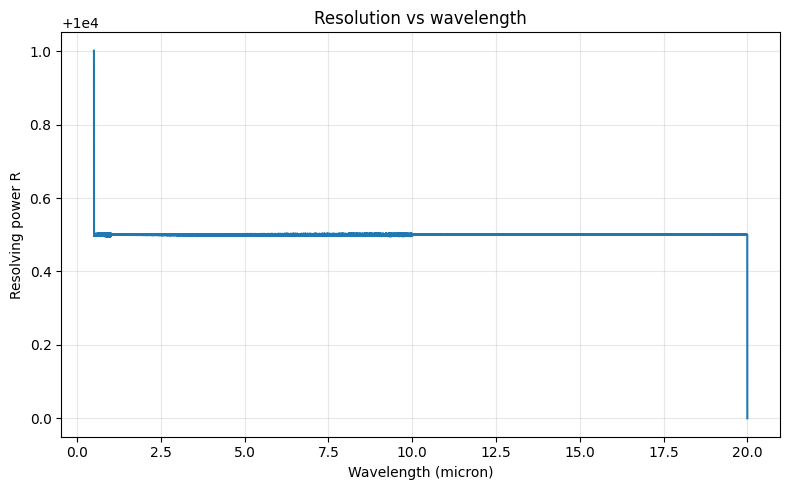

In [8]:
with h5py.File(hdf5_file, "r") as handle:
    group = handle[group_name]
    print(f"Group: {group_name}")
    print("Attributes:", dict(group.attrs))
    print("Datasets:", {name: dataset.shape for name, dataset in group.items()})

    nu = group["nu"][:]
    log_pressures = group["log(P)"][:]
    stored_temperatures = group["T"][:]
    log_sigma = group["log(sigma)"][:]

resolution = nu / np.gradient(nu)
print(
    "Resolution: "
    f"min={resolution.min():.2f}, max={resolution.max():.2f}, "
    f"mean={resolution.mean():.2f}, std={resolution.std():.2f}"
)

wavelength = 10_000 / nu
order = np.argsort(wavelength)
plt.figure(figsize=(8, 5))
plt.plot(wavelength[order], resolution[order])
plt.xlabel("Wavelength (micron)")
plt.ylabel("Resolving power R")
plt.title("Resolution vs wavelength")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

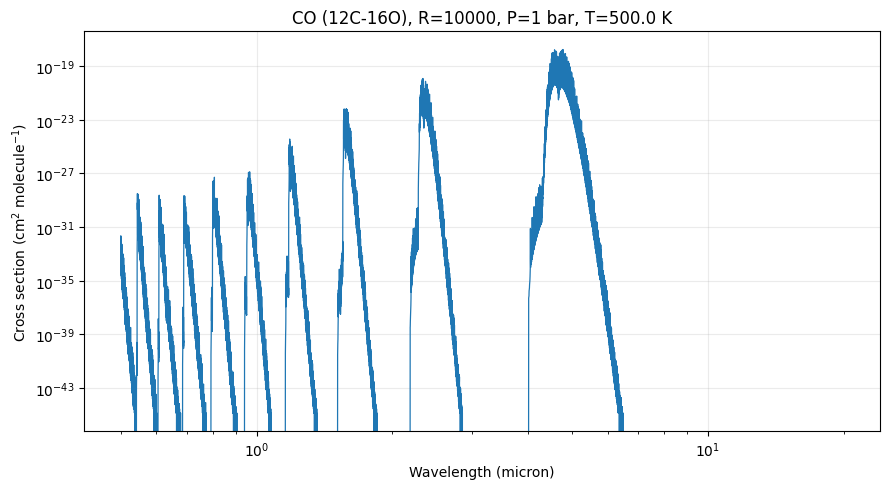

In [10]:
pressure_target = 1.0  # bar
temperature_target = 500.0  # K

pressure_index = np.abs(log_pressures - np.log10(pressure_target)).argmin()
temperature_index = np.abs(stored_temperatures - temperature_target).argmin()
pressure_used = 10 ** log_pressures[pressure_index]
temperature_used = stored_temperatures[temperature_index]
sigma = 10 ** log_sigma[pressure_index, temperature_index]

wavelength = 10_000 / nu
order = np.argsort(wavelength)

plt.figure(figsize=(9, 5))
plt.plot(wavelength[order], sigma[order], linewidth=0.9)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Wavelength (micron)")
plt.ylabel(r"Cross section (cm$^2$ molecule$^{-1}$)")
plt.title(
    f"{species} ({group_name}), R={target_R:g}, "
    f"P={pressure_used:.3g} bar, T={temperature_used:.1f} K"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()